## Testing additional length-based metrics

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../Datasets/Development_data.csv', encoding='utf-8')
len(df)

9068

Removing one- and two-sentence utterances to not influence the aggregation calculations 

In [3]:
sentence_count = df.groupby('ID').size()

one_sentence = (sentence_count == 1).sum()
two_sentence = (sentence_count == 2).sum()

print('No. of one-sentence utterances: ', one_sentence)
print('No. of one-sentence utterances: ', two_sentence)

df1 = df[df["ID"].isin(sentence_count[sentence_count >= 3].index)]
print(len(df1))

check = df1['ID'].unique()
print(len(check))
df1.head()

No. of one-sentence utterances:  107
No. of one-sentence utterances:  145
8671
548


,ID,sent_id,text_utt,text_sent,text_en,chair,annotation_utt,annotation_utt_score,annotation_sent,metadata
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...",Ni replike na repliko.,There's no replica to the replica.,True,N_Neutral,2.0,2.240412,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...
1,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...","Gospa ministrica, potem se boste lahko javili,...","Madam Minister, you'll be able to come forward...",True,N_Neutral,2.0,2.636969,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...
2,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...",Besedo pa ima gospod Gorenak.,Mr. Gorenak has the floor.,True,N_Neutral,2.0,3.639261,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...
3,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.seg3...,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,Hvala lepa.,Thank you very much.,True,P_Neutral,3.0,4.084590,{'Text_ID': 'ParlaMint-SI-en_2011-06-16-SDZ5-R...
4,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.seg3...,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,Besedo ima Silva Črnugelj.,"The word is ""silva blackugelj.""",True,P_Neutral,3.0,3.340636,{'Text_ID': 'ParlaMint-SI-en_2011-06-16-SDZ5-R...


### Sentence-count based avg

In [4]:
df1.loc[:, 'count'] = df1.groupby('ID')['sent_id'].transform('count')
count_avg = (
    df1.groupby('ID', group_keys=True)
    .apply(lambda x: (x['annotation_sent'] * x['count']).sum() / x['count'].sum())
    .reset_index(name='count_avg')
)

df1 = df1.merge(count_avg, on='ID')

df1["count_avg"] = df1["count_avg"].round(2)
df_count = df1.drop_duplicates(subset=['ID']).reset_index()

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df_count['annotation_utt_score'], df_count['count_avg'])
print(f"Mean Absolute Error (MAE): {mae}")

/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/1216435149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.loc[:, 'count'] = df1.groupby('ID')['sent_id'].transform('count')
/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/1216435149.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1.groupby('ID', group_keys=True)


Mean Absolute Error (MAE): 1.2387591240875913


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/2050493690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="annotation_utt_score", y="count_avg", data=df_count, palette='muted')


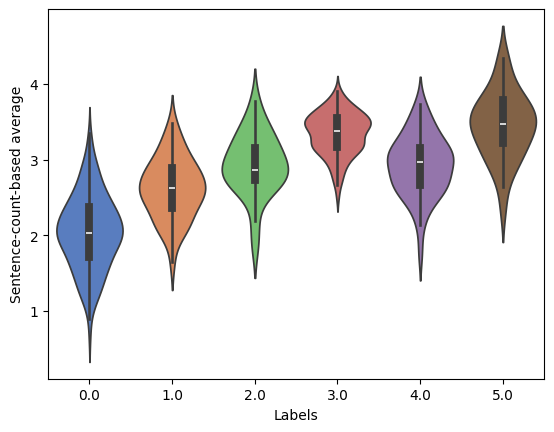

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.violinplot(x="annotation_utt_score", y="count_avg", data=df_count, palette='muted')
plt.xlabel("Labels")
plt.ylabel("Sentence-count-based average")
plt.show()

### Word-based length avg

In [6]:
df1["words"] = df1["text_sent"].apply(lambda x: len(x.split()))

# Compute the sentence-length-weighted average for each utterance
word_weighted_avg = (
    df1.groupby("ID")
    .apply(lambda group: (group["annotation_sent"] * group["words"]).sum() / group["words"].sum())
    .reset_index(name="word_avg")
)

# Add the length_avg back to the filtered DataFrame
df1 = df1.merge(word_weighted_avg, on="ID")

df1["word_avg"] = df1["word_avg"].round(2)
df_word = df1.drop_duplicates(subset=['ID']).reset_index()

mae = mean_absolute_error(df_word['annotation_utt_score'], df_word['word_avg'])
print(f"Mean Absolute Error (MAE): {mae}")

/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/825075954.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1.groupby("ID")


Mean Absolute Error (MAE): 1.051259124087591


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/224956828.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="annotation_utt", y="word_avg", data=df_word, palette='muted')


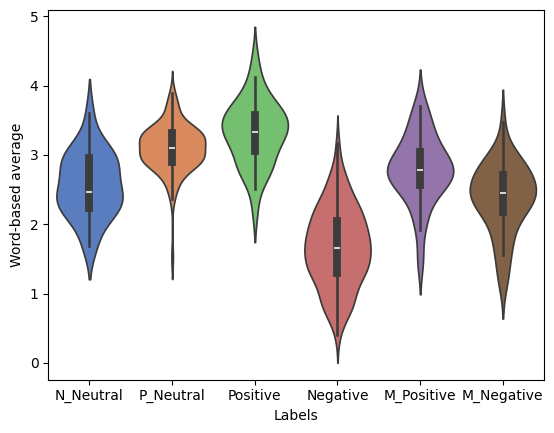

In [7]:
sns.violinplot(x="annotation_utt", y="word_avg", data=df_word, palette='muted')
plt.xlabel("Labels")
plt.ylabel("Word-based average")
plt.show()

### Character-based length avg

In [8]:
df1["char_length"] = df1["text_sent"].apply(len)
char_avg = (
    df1.groupby('ID')
    .apply(lambda x: (x["annotation_sent"] * x["char_length"]).sum() / x["char_length"].sum())
    .reset_index(name='char_avg')
)

df1 = df1.merge(char_avg, on='ID')

df_char = df1.drop_duplicates(subset=['ID']).reset_index()
mae = mean_absolute_error(df_char['annotation_utt_score'], df_char['char_avg'])

print(f"Mean Absolute Error (MAE): {mae}")

Mean Absolute Error (MAE): 1.0504567297120808


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/1040012026.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1.groupby('ID')


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1910/3243427683.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="annotation_utt_score", y="char_avg", data=df_char, palette='muted')


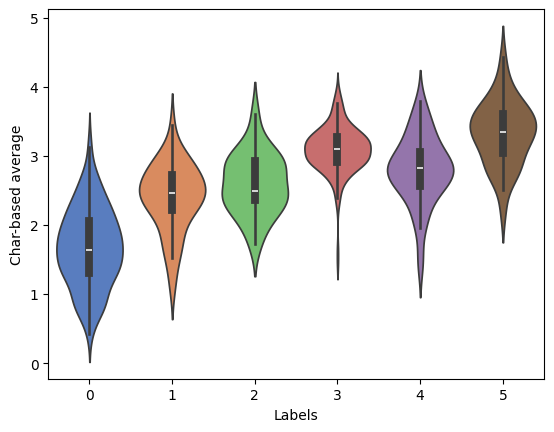

In [9]:
df_char['annotation_utt_score']=pd.Categorical(df_char['annotation_utt_score'],categories=[0,1,2,3,4,5])
sns.violinplot(x="annotation_utt_score", y="char_avg", data=df_char, palette='muted')
plt.xlabel("Labels")
plt.ylabel("Char-based average")
plt.show()

## Additional feature building

In [10]:
df1

,ID,sent_id,text_utt,text_sent,text_en,chair,annotation_utt,annotation_utt_score,annotation_sent,metadata,count,count_avg,words,word_avg,char_length,char_avg
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...",Ni replike na repliko.,There's no replica to the replica.,True,N_Neutral,2.0,2.240412,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...,3,2.84,4,2.81,22,2.803708
1,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...","Gospa ministrica, potem se boste lahko javili,...","Madam Minister, you'll be able to come forward...",True,N_Neutral,2.0,2.636969,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...,3,2.84,11,2.81,71,2.803708
2,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.se...,"Ni replike na repliko. Gospa ministrica, potem...",Besedo pa ima gospod Gorenak.,Mr. Gorenak has the floor.,True,N_Neutral,2.0,3.639261,{'Text_ID': 'ParlaMint-SI-en_2010-09-07-SDZ5-I...,3,2.84,5,2.81,29,2.803708
3,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.seg3...,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,Hvala lepa.,Thank you very much.,True,P_Neutral,3.0,4.084590,{'Text_ID': 'ParlaMint-SI-en_2011-06-16-SDZ5-R...,3,3.49,2,3.27,11,3.265325
4,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.seg3...,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,Besedo ima Silva Črnugelj.,"The word is ""silva blackugelj.""",True,P_Neutral,3.0,3.340636,{'Text_ID': 'ParlaMint-SI-en_2011-06-16-SDZ5-R...,3,3.49,4,3.27,26,3.265325
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8666,ParlaMint-SI_2014-03-03-SDZ6-Redna-22.ana.u242,ParlaMint-SI_2014-03-03-SDZ6-Redna-22.ana.seg8...,"Hvala za besedo, predsedujoča. Pozdrav vsem pr...",Hvala.,Thank you.,False,M_Negative,1.0,4.510695,{'Text_ID': 'ParlaMint-SI-en_2014-03-03-SDZ6-R...,15,3.17,1,3.02,6,3.017512
8667,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.ana.u95,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.ana.se...,"Hvala, gospodu Kovačiču. Da se ne bi še kdo zm...","Hvala, gospodu Kovačiču.","Thank you, Mr. Kovacich.",True,P_Neutral,3.0,4.017726,{'Text_ID': 'ParlaMint-SI-en_2005-02-01-SDZ4-I...,4,3.08,3,2.49,24,2.634149
8668,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.ana.u95,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.ana.se...,"Hvala, gospodu Kovačiču. Da se ne bi še kdo zm...","Da se ne bi še kdo zmotil, obrazložitve glasu ...","Not to be mistaken, the explanation of the voi...",True,P_Neutral,3.0,1.817976,{'Text_ID': 'ParlaMint-SI-en_2005-02-01-SDZ4-I...,4,3.08,16,2.49,85,2.634149
8669,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.ana.u95,ParlaMint-SI_2005-02-01-SDZ4-Izredna-06.ana.se...,"Hvala, gospodu Kovačiču. Da se ne bi še kdo zm...",Svoje stališče oziroma obrazložitev glasu bo g...,"Mr Grimes, please, will explain his position o...",True,P_Neutral,3.0,3.074007,{'Text_ID': 'ParlaMint-SI-en_2005-02-01-SDZ4-I...,4,3.08,9,2.49,66,2.634149


In [11]:
columns = ['ID', 'annotation_sent', 'annotation_utt_score', 'count', 'char_length', 'char_avg']
df1 = df1[columns]
aggregation = df1.groupby('ID')['annotation_sent'].agg(
    mean = 'mean',
    median = 'median'
)

df1 = df1.merge(aggregation, on='ID')
df1['sum'] = df1.groupby('ID')['char_length'].transform('sum')
df1['Q1'] = df1.groupby('ID')['annotation_sent'].transform(lambda x: x.quantile(0.25))
df1['Q3'] = df1.groupby('ID')['annotation_sent'].transform(lambda x: x.quantile(0.75))
df1 = df1.drop(columns=['char_length'])
df1.head()

,ID,annotation_sent,annotation_utt_score,count,char_avg,mean,median,sum,Q1,Q3
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.240412,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
1,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.636969,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
2,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,3.639261,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
3,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,4.084590,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613
4,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,3.340636,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613


In [13]:
data = df1.drop_duplicates(subset=['ID']).reset_index(drop=True)
data.head()

,ID,annotation_sent,annotation_utt_score,count,char_avg,mean,median,sum,Q1,Q3
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.ana.u90,2.240412,2.0,3,2.803708,2.838881,2.636969,122,2.438690,3.138115
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.ana.u107,4.084590,3.0,3,3.265325,3.491818,3.340636,88,3.195431,3.712613
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.ana.u178,4.084590,5.0,15,3.044246,3.235311,3.166192,2442,2.545302,3.812141
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.ana.u276,3.971972,0.0,32,1.788266,1.978221,1.869849,3646,0.537923,2.955510
4,ParlaMint-SI_2021-10-18-SDZ8-Redna-26.ana.u273,1.713008,0.0,19,1.376532,1.879965,2.262624,2159,0.367626,2.710190
